### State Schema's
- using TypedDict
- using DataClasses
- pydantic

https://docs.langchain.com/oss/python/langgraph/graph-api

In [46]:
# create state schema using typedict
from typing_extensions import TypedDict
from typing import Literal

class TypedDictState(TypedDict):
    name:str
    game:Literal["cricket","badminton"]

In [47]:
# create nodes
def play_game(state: TypedDictState):
    print("---Play Game node has been called--")
    return {"name": state["name"] + " want to play "}


def cricket(state: TypedDictState):
    print("-- Cricket node has been called--")
    return {"game": "cricket"}


def badminton(state: TypedDictState):
    print("-- badminton node has been called--")
    return {"game": "badminton"}

In [48]:
# add a conditional node
import random


def decide_play(state: TypedDictState) -> Literal["cricket", "badminton"]:
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

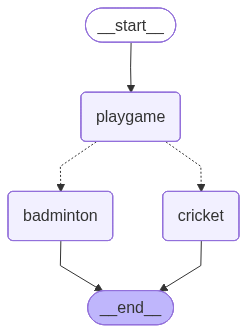

In [49]:
# create the graph structure
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(TypedDictState)
builder.add_node("playgame", play_game)
builder.add_node("cricket", cricket)
builder.add_node("badminton", badminton)

## Flow of the graph

builder.add_edge(START, "playgame")
builder.add_conditional_edges("playgame", decide_play)
builder.add_edge("cricket", END)
builder.add_edge("badminton", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
graph.invoke({"name":"Dennis"})

---Play Game node has been called--
-- Cricket node has been called--


{'name': 'Dennis want to play ', 'game': 'cricket'}

### DataClass

In [43]:
from dataclasses import dataclass


@dataclass
class DataClassState:
    name: str
    game: Literal["badminton", "cricket"]

In [44]:
# add nodes
def play_game(state: DataClassState):
    print("---Play Game node has been called--")
    return {"name": state.name + " want to play "}


def cricket(state: DataClassState):
    print("-- Cricket node has been called--")
    return {"name": state.name + " cricket", "game": "cricket"}


def badminton(state: DataClassState):
    print("-- badminton node has been called--")
    return {"name": state.name + " badminton", "game": "badminton"}

In [45]:
# create conditional node
import random


def decide_play(state: DataClassState) -> Literal["cricket", "badminton"]:
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

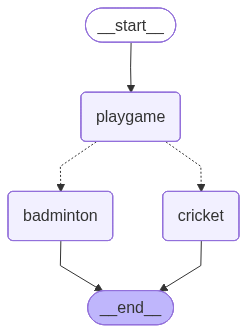

In [51]:
# configure graph


builder = StateGraph(DataClassState)
builder.add_node("playgame", play_game)
builder.add_node("cricket", cricket)
builder.add_node("badminton", badminton)

## Flow of the graph

builder.add_edge(START, "playgame")
builder.add_conditional_edges("playgame", decide_play)
builder.add_edge("cricket", END)
builder.add_edge("badminton", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [54]:
graph.invoke(DataClassState(name="Dennis", game="cricket"))

---Play Game node has been called--
-- badminton node has been called--


{'name': 'Dennis want to play ', 'game': 'badminton'}

### Pydantic

In [60]:
from pydantic import BaseModel


class State(BaseModel):
    name: str

In [63]:
# create Nodes
def say_hello(state: State):
    print("---First Node is called")
    return {"name": "Hello"}

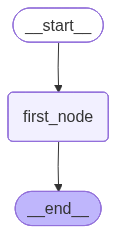

In [64]:
# structure the graph

builder = StateGraph(State)
builder.add_node("first_node", say_hello)

builder.add_edge(START, "first_node")
builder.add_edge("first_node", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [65]:
graph.invoke({"name": "hello"})

---First Node is called


{'name': 'Hello'}